In [ ]:
!pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 21.4 MB/s eta 0:00:00


In [ ]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import av
import numpy as np

class VideoCaptionDataset(Dataset):
    def __init__(self, videos_dir, csv_path, image_processor, tokenizer, num_frames=8, max_length=128):
        self.videos_dir = videos_dir
        self.data = pd.read_csv(csv_path)
        self.processor = image_processor
        self.tokenizer = tokenizer
        self.num_frames = num_frames
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get video ID and Nepali caption
        video_id = self.data.loc[idx, "video_id"]
        caption = str(self.data.loc[idx, "nepali_caption"])

        # Load video and sample frames
        video_path = os.path.join(self.videos_dir, f"{video_id}.avi")
        container = av.open(video_path)
        total_frames = container.streams.video[0].frames
        # Uniformly sample frame indices
        indices = np.linspace(0, total_frames - 1, num=self.num_frames, dtype=np.int64)
        frames = []
        container.seek(0)
        for i, frame in enumerate(container.decode(video=0)):
            if i in indices:
                # Convert frame to RGB array
                arr = frame.to_ndarray(format="rgb24")
                frames.append(arr)
        # Process frames into pixel_values tensor
        pixel_values = self.processor(frames, return_tensors="pt").pixel_values  # shape [1, num_frames, 3, H, W]

        # Tokenize Nepali caption
        encoding = self.tokenizer(caption, padding="max_length", truncation=True,
                                   max_length=self.max_length, return_tensors="pt")
        labels = encoding.input_ids
        # Replace tokenizer.pad_token_id with -100 to ignore in loss
        labels[labels == self.tokenizer.pad_token_id] = -100

        return pixel_values.squeeze(), labels.squeeze()


In [ ]:
import os
from transformers import AutoImageProcessor, MBart50TokenizerFast



# Paths to splits
train_dir = "/content/drive/MyDrive/msvd_splitted/train"
val_dir   = "/content/drive/MyDrive/msvd_splitted/val"
test_dir  = "/content/drive/MyDrive/msvd_splitted/test"

# Image processor and tokenizer initialization
image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
tokenizer.src_lang = "en_XX"    # (Not used for images, but required attribute)
tokenizer.tgt_lang = "ne_NP"    # target Nepali

# Create datasets
train_dataset = VideoCaptionDataset(os.path.join(train_dir, "videos"),
                                    os.path.join(train_dir, "train.csv"),
                                    image_processor, tokenizer)
val_dataset   = VideoCaptionDataset(os.path.join(val_dir, "videos"),
                                    os.path.join(val_dir, "val.csv"),
                                    image_processor, tokenizer)
test_dataset  = VideoCaptionDataset(os.path.join(test_dir, "videos"),
                                    os.path.join(test_dir, "test.csv"),
                                    image_processor, tokenizer)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/412 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [ ]:
import torch
import torch.nn as nn
from transformers import TimesformerModel, MBartForConditionalGeneration


class VideoCaptioningModel(nn.Module):
    def __init__(self, encoder_name="facebook/timesformer-base-finetuned-k400", decoder_name="facebook/mbart-large-50-many-to-many-mmt"):
        super().__init__()
        # Load pretrained TimeSformer encoder (base, output raw hidden states)
        self.encoder = TimesformerModel.from_pretrained(encoder_name)
        enc_hidden_size = self.encoder.config.hidden_size  # 768 for base
        # Load pretrained mBART decoder
        self.decoder = MBartForConditionalGeneration.from_pretrained(decoder_name)
        dec_hidden_size = self.decoder.config.d_model  # 1024 for mbart-large-50
        # Simple adapter to match dims if needed
        if enc_hidden_size != dec_hidden_size:
            self.adapter = nn.Linear(enc_hidden_size, dec_hidden_size)
        else:
            self.adapter = None

    def forward(self, pixel_values, labels=None):
        # Encode video frames
        encoder_outputs = self.encoder(pixel_values, return_dict=True)
        encoder_hidden_states = encoder_outputs.last_hidden_state
        # Adapter projection
        if self.adapter:
            encoder_hidden_states = self.adapter(encoder_hidden_states)
        # Prepare decoder inputs: use encoder outputs as context
        outputs = self.decoder(
            encoder_outputs=(encoder_hidden_states,),
            labels=labels,
            return_dict=True
        )
        return outputs

# Instantiate model
torch.cuda.empty_cache()
model = VideoCaptioningModel()
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# Update decoder_start_token_id for Nepali and pad token id
tokenizer.tgt_lang = "ne_NP"
model.decoder.config.decoder_start_token_id = tokenizer.lang_code_to_id["ne_NP"]
model.decoder.config.pad_token_id = tokenizer.pad_token_id


pytorch_model.bin:   0%|          | 0.00/486M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/486M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
dummy_pixel = torch.randn(1,8,3,224,224).to(device)
dummy_labels = torch.randint(0, tokenizer.vocab_size, (1,128)).to(device)
print("\n" + "="*80)
print("Full Model Summary:")
summary(model,
        input_data=[dummy_pixel, dummy_labels],
        verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        depth=5)




Full Model Summary:
Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Kernel Shape
VideoCaptioningModel                                              [1, 8, 3, 224, 224]       [1, 1569, 1024]           --                        --
├─TimesformerModel: 1-1                                           [1, 8, 3, 224, 224]       [1, 1569, 768]            --                        --
│    └─TimesformerEmbeddings: 2-1                                 [1, 8, 3, 224, 224]       [1, 1569, 768]            158,208                   --
│    │    └─TimesformerPatchEmbeddings: 3-1                       [1, 8, 3, 224, 224]       [8, 196, 768]             --                        --
│    │    │    └─Conv2d: 4-1                                      [8, 3, 224, 224]          [8, 768, 14, 14]          590,592                   [16, 16]
│    │    └─Dropout: 3-2                                          [8, 197, 768]  

Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Kernel Shape
VideoCaptioningModel                                              [1, 8, 3, 224, 224]       [1, 1569, 1024]           --                        --
├─TimesformerModel: 1-1                                           [1, 8, 3, 224, 224]       [1, 1569, 768]            --                        --
│    └─TimesformerEmbeddings: 2-1                                 [1, 8, 3, 224, 224]       [1, 1569, 768]            158,208                   --
│    │    └─TimesformerPatchEmbeddings: 3-1                       [1, 8, 3, 224, 224]       [8, 196, 768]             --                        --
│    │    │    └─Conv2d: 4-1                                      [8, 3, 224, 224]          [8, 768, 14, 14]          590,592                   [16, 16]
│    │    └─Dropout: 3-2                                          [8, 197, 768]             [8, 197, 7

In [ ]:
# Take one batch from train loader
pixel_vals, labels = next(iter(train_loader))
pixel_vals = pixel_vals.to(device)

# Pass through encoder
with torch.no_grad():
    encoder_outputs = model.encoder(pixel_vals, return_dict=True)
    video_embeddings = encoder_outputs.last_hidden_state  # Shape: [B, num_tokens, hidden_size]

print("Video Embeddings Shape:", video_embeddings.shape)

Video Embeddings Shape: torch.Size([1, 1569, 768])


In [ ]:
print("First token embedding (first video):", video_embeddings[0, 0,:10].cpu().numpy())  # First 10 values

First token embedding (first video): [-0.25323203  0.7027501  -2.669809   -0.60380703 -0.40105963 -1.7106961
 -1.4002268   0.59547347  0.42508745  0.7529034 ]


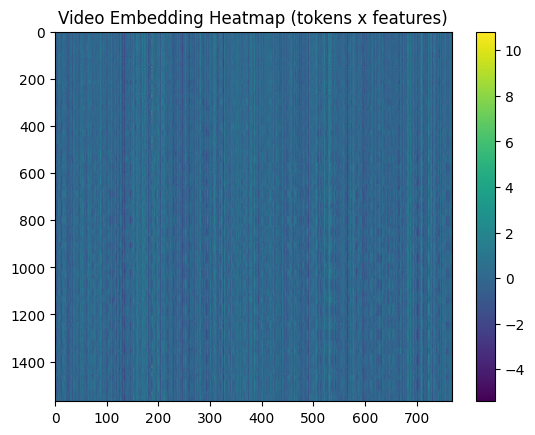

In [ ]:
# Optionally visualize with matplotlib (for first video token embeddings)
import matplotlib.pyplot as plt
plt.imshow(video_embeddings[0].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Video Embedding Heatmap (tokens x features)")
plt.show()

In [ ]:
# Example: visualize tokenizer output for the first caption in train.csv
sample_caption = pd.read_csv(os.path.join(train_dir, "train.csv")).iloc[0]["nepali_caption"]
print("Original Caption:", sample_caption)

# Tokenize
encoding = tokenizer(sample_caption, padding="max_length", truncation=True, max_length=128)
print("Token IDs:", encoding["input_ids"])

# Decode back
decoded_text = tokenizer.decode(encoding["input_ids"], skip_special_tokens=True)
print("Decoded Caption:", decoded_text)


Original Caption: कसैले एउटा सानो बिरालोको बच्चा पालेको छ जो तारमा चपिरहेको छ
Token IDs: [250004, 148655, 27605, 160596, 5948, 2815, 9376, 356, 76396, 83092, 14470, 848, 4993, 136962, 411, 2922, 2138, 68712, 848, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Decoded Caption: कसैले एउटा सानो बिरालोको बच्चा पालेको छ जो तारमा चपिरहेको छ


In [ ]:
import torch.optim as optim
from tqdm import tqdm

num_epochs = 5
optimizer = optim.Adam(model.parameters(), lr=5e-5)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    total_loss, total_acc, count = 0.0, 0.0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Training")
    for pixel_vals, labels in loop:
        pixel_vals = pixel_vals.to(device)       # [B, 8, 3, H, W]
        labels = labels.to(device)               # [B, max_length]
        optimizer.zero_grad()
        outputs = model(pixel_vals, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # Compute token-level accuracy (ignoring padded tokens)
        logits = outputs.logits                # [B, seq_len, vocab_size]
        preds = torch.argmax(logits, dim=-1)   # [B, seq_len]
        # Mask to exclude padding (-100 in labels)
        mask = (labels != -100)
        correct = (preds == labels) * mask
        if mask.sum().item() > 0:
            acc = correct.sum().float() / mask.sum().float()
            total_acc += acc.item()
            count += 1
        loop.set_postfix(loss=loss.item(), acc=(acc.item() if mask.sum()>0 else 0))

    avg_train_loss = total_loss / len(train_loader)
    avg_train_acc  = total_acc / count if count > 0 else 0
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    # ---- Validation ----
    model.eval()
    val_loss, val_acc, val_count = 0.0, 0.0, 0
    with torch.no_grad():
        vloop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Validation")
        for pixel_vals, labels in vloop:
            pixel_vals = pixel_vals.to(device)
            labels = labels.to(device)
            outputs = model(pixel_vals, labels=labels)
            loss = outputs.loss
            val_loss += loss.item()
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            mask = (labels != -100)
            correct = (preds == labels) * mask
            if mask.sum().item() > 0:
                acc = correct.sum().float() / mask.sum().float()
                val_acc += acc.item()
                val_count += 1
            vloop.set_postfix(val_loss=loss.item(), val_acc=(acc.item() if mask.sum()>0 else 0))

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = val_acc / val_count if val_count > 0 else 0
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}; "
          f"Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.4f}")


Epoch [1/5] Training:   0%|          | 1/49121 [01:13<999:39:55, 73.27s/it, acc=0.111, loss=11.8]

In [ ]:
def save_model(model, path='model.pth'):
    """Save the entire PyTorch model (encoder+adapter+decoder) to disk."""
    torch.save(model, path)
    print(f"Model saved to {path}")

save_model(model)

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs+1)

plt.figure(figsize=(12,5))
# Plot Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Acc")
plt.plot(epochs, val_accs,   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from evaluate import load as load_metric

# Load evaluation metrics
bleu_metric  = load_metric("bleu")
cider_metric = load_metric("cider")
rouge_metric = load_metric("rouge")
meteor_metric= load_metric("meteor")

model.eval()
predictions, references = [], []

for pixel_vals, labels in tqdm(test_loader, desc="Evaluating on Test"):
    pixel_vals = pixel_vals.to(device)
    # Generate caption tokens
    generated_ids = model.decoder.generate(
        encoder_outputs=(model.encoder(pixel_vals, return_dict=True).last_hidden_state,),
        forced_bos_token_id=tokenizer.lang_code_to_id["ne_NP"],
        max_length=tokenizer.model_max_length,
        num_beams=4
    )
    # Decode to text
    gen_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    true_ids = labels.squeeze().tolist()
    # Convert target ids to string (handle -100 and special tokens)
    labels[labels == -100] = tokenizer.pad_token_id
    ref_text = tokenizer.batch_decode([true_ids], skip_special_tokens=True)[0]
    predictions.append(gen_text[0])
    references.append(ref_text)

# Compute metrics
bleu_score  = bleu_metric.compute(predictions=predictions, references=[[ref] for ref in references])
cider_score = cider_metric.compute(predictions=predictions, references=[references])
rouge_score = rouge_metric.compute(predictions=predictions, references=references)
meteor_score= meteor_metric.compute(predictions=predictions, references=references)

print(f"BLEU:  {bleu_score['bleu']:.4f}")
print(f"CIDEr: {cider_score['cider']:.4f}")
print(f"ROUGE: {rouge_score['rouge1']:.4f}")
print(f"METEOR:{meteor_score['meteor']:.4f}")
